In [ ]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

In [ ]:
# Load dataset
df = pd.read_csv('Breast Cancer METABRIC.csv')

# Display first 5 rows
df.head()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 status measured by SNP6,HER2 Status,Tumor Other Histologic Subtype,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall Survival (Months),Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,Positive,2.0,Neutral,Negative,Ductal/NST,Yes,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,Positive,2.0,Neutral,Negative,Mixed,Yes,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,Positive,3.0,Neutral,Negative,Mixed,Yes,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


In [ ]:
# Dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2509
Number of columns: 34


In [ ]:
# Column names
df.columns.tolist()

['Patient ID',
 'Age at Diagnosis',
 'Type of Breast Surgery',
 'Cancer Type',
 'Cancer Type Detailed',
 'Cellularity',
 'Chemotherapy',
 'Pam50 + Claudin-low subtype',
 'Cohort',
 'ER status measured by IHC',
 'ER Status',
 'Neoplasm Histologic Grade',
 'HER2 status measured by SNP6',
 'HER2 Status',
 'Tumor Other Histologic Subtype',
 'Hormone Therapy',
 'Inferred Menopausal State',
 'Integrative Cluster',
 'Primary Tumor Laterality',
 'Lymph nodes examined positive',
 'Mutation Count',
 'Nottingham prognostic index',
 'Oncotree Code',
 'Overall Survival (Months)',
 'Overall Survival Status',
 'PR Status',
 'Radio Therapy',
 'Relapse Free Status (Months)',
 'Relapse Free Status',
 'Sex',
 '3-Gene classifier subtype',
 'Tumor Size',
 'Tumor Stage',
 "Patient's Vital Status"]

In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Patient ID                      2509 non-null   object 
 1   Age at Diagnosis                2498 non-null   float64
 2   Type of Breast Surgery          1955 non-null   object 
 3   Cancer Type                     2509 non-null   object 
 4   Cancer Type Detailed            2509 non-null   object 
 5   Cellularity                     1917 non-null   object 
 6   Chemotherapy                    1980 non-null   object 
 7   Pam50 + Claudin-low subtype     1980 non-null   object 
 8   Cohort                          2498 non-null   float64
 9   ER status measured by IHC       2426 non-null   object 
 10  ER Status                       2469 non-null   object 
 11  Neoplasm Histologic Grade       2388 non-null   float64
 12  HER2 status measured by SNP6    19

In [ ]:
# Statistical summary
df.describe()

,Age at Diagnosis,Cohort,Neoplasm Histologic Grade,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Relapse Free Status (Months),Tumor Size,Tumor Stage
count,2498.000000,2498.000000,2388.000000,2243.000000,2357.000000,2287.000000,1981.000000,2388.000000,2360.000000,1788.000000
mean,60.420300,2.900320,2.412060,1.950513,5.578702,4.028787,125.244271,108.842487,26.220093,1.713647
std,13.032997,1.962216,0.649363,4.017774,3.967967,1.189092,76.111772,76.519494,15.370883,0.655307
min,21.930000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,50.920000,1.000000,2.000000,0.000000,3.000000,3.048000,60.866667,40.560000,17.000000,1.000000
50%,61.110000,3.000000,3.000000,0.000000,5.000000,4.044000,116.466667,99.095000,22.410000,2.000000
75%,70.000000,4.000000,3.000000,2.000000,7.000000,5.040000,185.133333,167.640000,30.000000,2.000000
max,96.290000,9.000000,3.000000,45.000000,80.000000,7.200000,355.200000,384.210000,182.000000,4.000000


In [ ]:
df.describe(include='object')

,Patient ID,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,ER status measured by IHC,ER Status,HER2 status measured by SNP6,HER2 Status,Tumor Other Histologic Subtype,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Oncotree Code,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status,Sex,3-Gene classifier subtype,Patient's Vital Status
count,2509,1955,2509,2509,1917,1980,1980,2426,2469,1980,1980,2374,1980,1980,1980,1870,2509,1981,1980,1980,2488,2509,1764,1980
unique,2509,2,2,8,3,2,7,2,2,4,2,8,2,2,11,2,8,2,2,2,2,1,4,3
top,MTS-T2432,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,Positve,Positive,Neutral,Negative,Ductal/NST,Yes,Post,8,Left,IDC,Deceased,Positive,Yes,Not Recurred,Female,ER+/HER2- Low Prolif,Living
freq,1,1170,2506,1865,965,1568,700,1817,1825,1436,1733,1810,1216,1556,299,973,1865,1144,1040,1173,1486,2509,640,837


In [ ]:
# Missing values count
missing_values = df.isnull().sum()

# Show only columns with missing values
missing_values[missing_values > 0].sort_values(ascending=False)

,0
3-Gene classifier subtype,745
Tumor Stage,721
Primary Tumor Laterality,639
Cellularity,592
Type of Breast Surgery,554
HER2 status measured by SNP6,529
Hormone Therapy,529
PR Status,529
Radio Therapy,529
Inferred Menopausal State,529


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percentage
})

missing_df[missing_df['Missing Values'] > 0].sort_values(
    by='Percentage',
    ascending=False
)

,Missing Values,Percentage
3-Gene classifier subtype,745,29.693105
Tumor Stage,721,28.736548
Primary Tumor Laterality,639,25.468314
Cellularity,592,23.595058
Type of Breast Surgery,554,22.080510
HER2 status measured by SNP6,529,21.084097
Hormone Therapy,529,21.084097
PR Status,529,21.084097
Radio Therapy,529,21.084097
Inferred Menopausal State,529,21.084097


In [ ]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.columns.tolist()

['Patient ID',
 'Age at Diagnosis',
 'Type of Breast Surgery',
 'Cancer Type',
 'Cancer Type Detailed',
 'Cellularity',
 'Chemotherapy',
 'Pam50 + Claudin-low subtype',
 'Cohort',
 'ER status measured by IHC',
 'ER Status',
 'Neoplasm Histologic Grade',
 'HER2 status measured by SNP6',
 'HER2 Status',
 'Tumor Other Histologic Subtype',
 'Hormone Therapy',
 'Inferred Menopausal State',
 'Integrative Cluster',
 'Primary Tumor Laterality',
 'Lymph nodes examined positive',
 'Mutation Count',
 'Nottingham prognostic index',
 'Oncotree Code',
 'Overall Survival (Months)',
 'Overall Survival Status',
 'PR Status',
 'Radio Therapy',
 'Relapse Free Status (Months)',
 'Relapse Free Status',
 'Sex',
 '3-Gene classifier subtype',
 'Tumor Size',
 'Tumor Stage',
 "Patient's Vital Status"]

In [ ]:
# Remove unnecessary column
df.drop('Patient ID', axis=1, inplace=True)

# Check shape after dropping
df.shape

(2509, 33)

In [ ]:
# Target variable distribution
df['Overall Survival Status'].value_counts()

,count
Overall Survival Status,
Deceased,1144
Living,837


In [ ]:
df['Overall Survival Status'].value_counts(normalize=True) * 100

,proportion
Overall Survival Status,
Deceased,57.748612
Living,42.251388


In [ ]:
# Missing values
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

3-Gene classifier subtype         745
Tumor Stage                       721
Primary Tumor Laterality          639
Cellularity                       592
Type of Breast Surgery            554
HER2 status measured by SNP6      529
Hormone Therapy                   529
PR Status                         529
Radio Therapy                     529
Inferred Menopausal State         529
Chemotherapy                      529
Pam50 + Claudin-low subtype       529
HER2 Status                       529
Integrative Cluster               529
Patient's Vital Status            529
Overall Survival Status           528
Overall Survival (Months)         528
Lymph nodes examined positive     266
Nottingham prognostic index       222
Mutation Count                    152
Tumor Size                        149
Tumor Other Histologic Subtype    135
Neoplasm Histologic Grade         121
Relapse Free Status (Months)      121
ER status measured by IHC          83
ER Status                          40
Relapse Free

In [ ]:
# Numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Categorical columns
categorical_cols = df.select_dtypes(include='object').columns

print("Numerical columns:", len(numerical_cols))
print("Categorical columns:", len(categorical_cols))

Numerical columns: 10
Categorical columns: 23


In [ ]:
# Fill numerical missing values
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [ ]:
# Fill categorical missing values
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [ ]:
# Check remaining missing values
df.isnull().sum().sum()

np.int64(0)

In [ ]:
# Duplicate rows
print("Duplicates:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

Duplicates: 6


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
le = LabelEncoder()

# Encode categorical columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2503 entries, 0 to 2507
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age at Diagnosis                2503 non-null   float64
 1   Type of Breast Surgery          2503 non-null   int64  
 2   Cancer Type                     2503 non-null   int64  
 3   Cancer Type Detailed            2503 non-null   int64  
 4   Cellularity                     2503 non-null   int64  
 5   Chemotherapy                    2503 non-null   int64  
 6   Pam50 + Claudin-low subtype     2503 non-null   int64  
 7   Cohort                          2503 non-null   float64
 8   ER status measured by IHC       2503 non-null   int64  
 9   ER Status                       2503 non-null   int64  
 10  Neoplasm Histologic Grade       2503 non-null   float64
 11  HER2 status measured by SNP6    2503 non-null   int64  
 12  HER2 Status                     2503 no

In [ ]:
df.to_csv('cleaned_breast_cancer.csv', index=False)

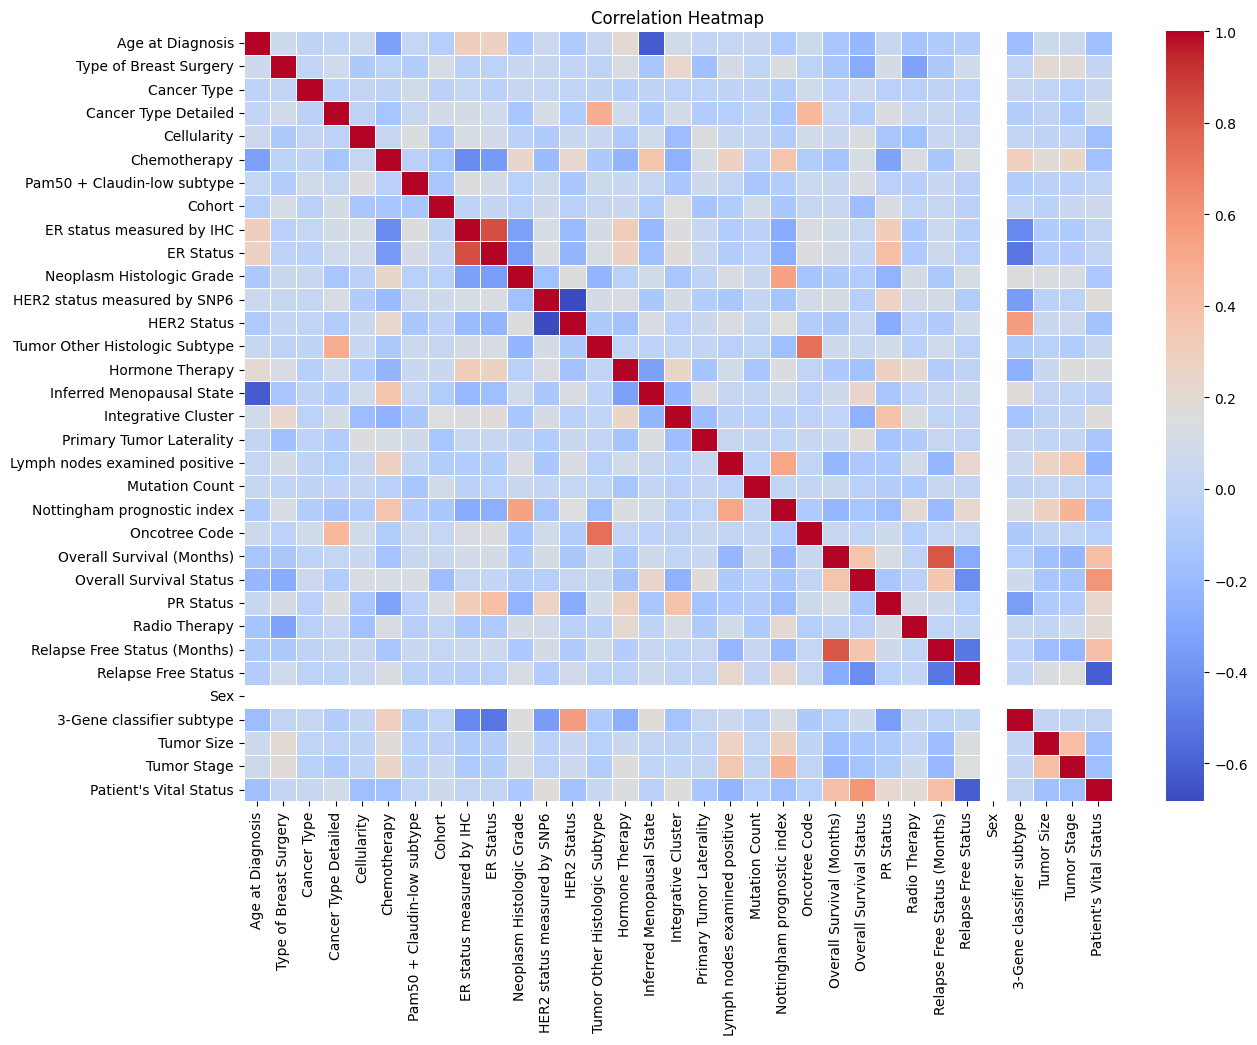

In [ ]:
# Correlation matrix
plt.figure(figsize=(14,10))

corr = df.corr()

sns.heatmap(corr,
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Correlation Heatmap')
plt.show()

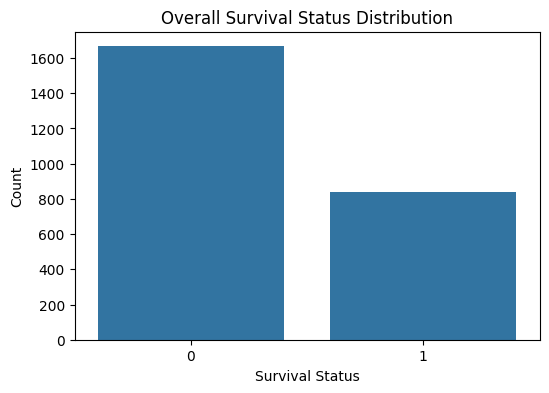

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='Overall Survival Status', data=df)

plt.title('Overall Survival Status Distribution')
plt.xlabel('Survival Status')
plt.ylabel('Count')

plt.show()

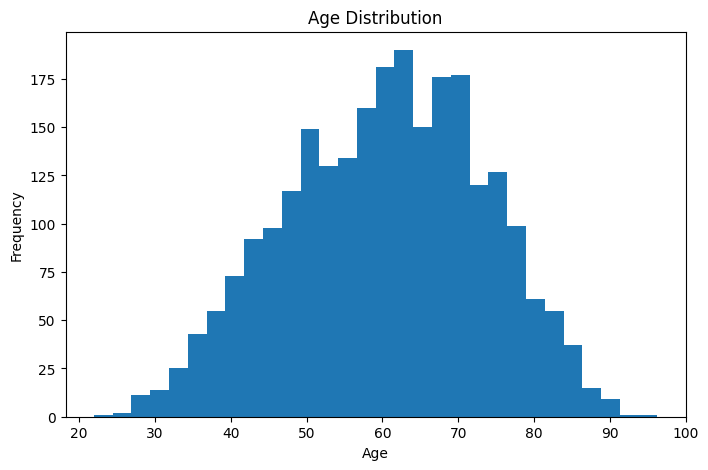

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['Age at Diagnosis'],
         bins=30)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

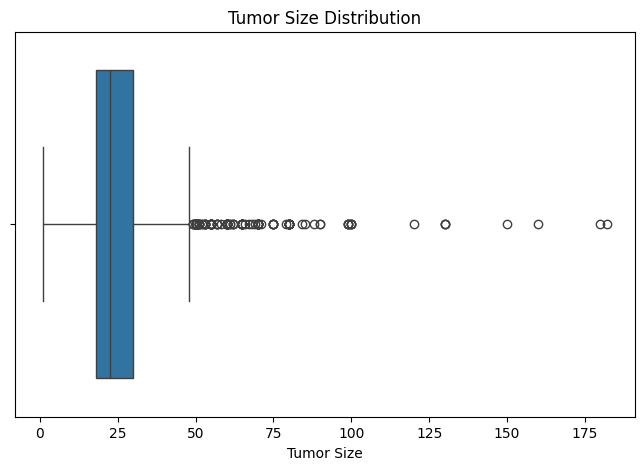

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Tumor Size'])

plt.title('Tumor Size Distribution')

plt.show()

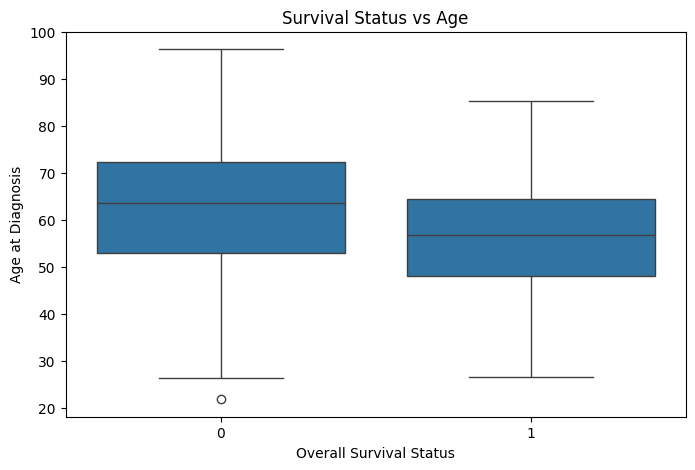

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Overall Survival Status',
            y='Age at Diagnosis',
            data=df)

plt.title('Survival Status vs Age')
plt.show()

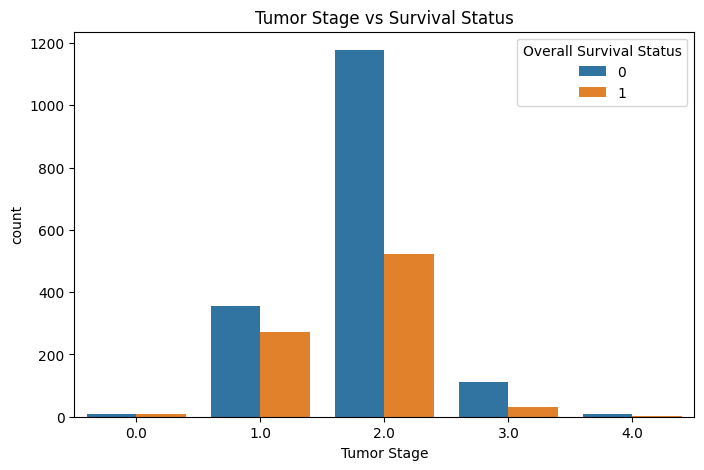

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Tumor Stage',
              hue='Overall Survival Status',
              data=df)

plt.title('Tumor Stage vs Survival Status')
plt.show()

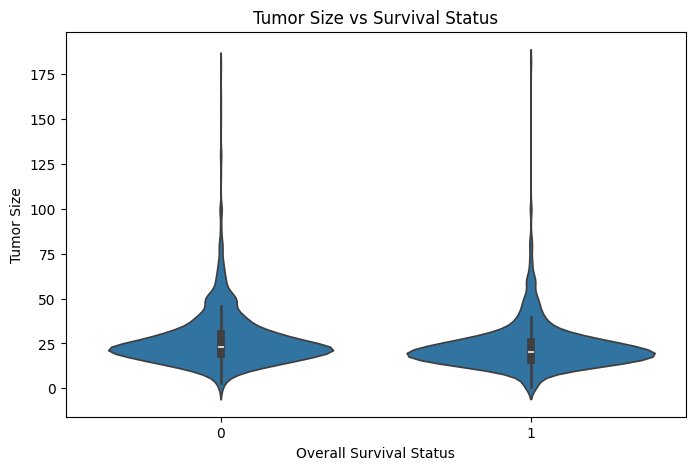

In [ ]:
plt.figure(figsize=(8,5))

sns.violinplot(x='Overall Survival Status',
               y='Tumor Size',
               data=df)

plt.title('Tumor Size vs Survival Status')
plt.show()

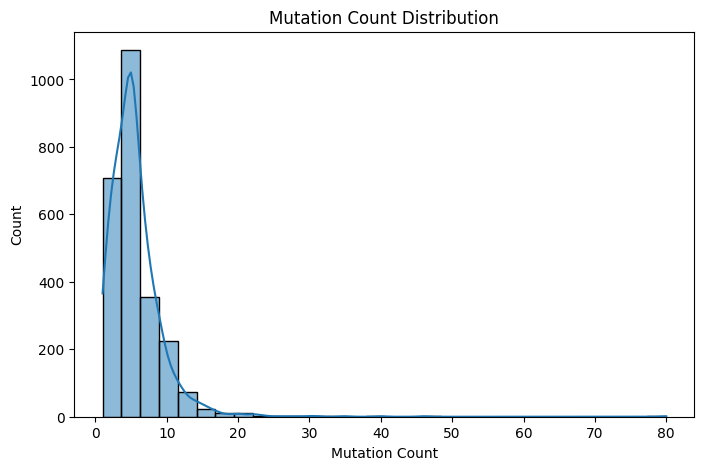

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Mutation Count'],
             bins=30,
             kde=True)

plt.title('Mutation Count Distribution')
plt.show()

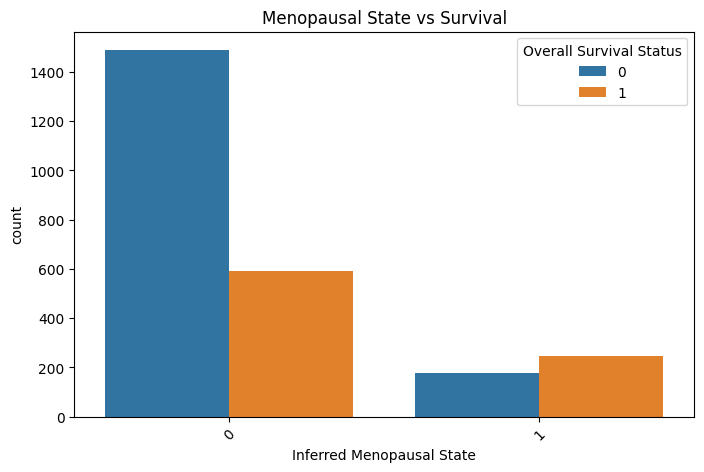

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Inferred Menopausal State',
              hue='Overall Survival Status',
              data=df)

plt.xticks(rotation=45)

plt.title('Menopausal State vs Survival')
plt.show()

In [ ]:
df[['Age at Diagnosis',
    'Tumor Size',
    'Mutation Count',
    'Tumor Stage']].describe()

,Age at Diagnosis,Tumor Size,Mutation Count,Tumor Stage
count,2503.000000,2503.000000,2503.000000,2503.000000
mean,60.428913,26.002417,5.546544,1.799441
std,13.015350,14.951349,3.851787,0.563093
min,21.930000,1.000000,1.000000,0.000000
25%,50.930000,18.000000,3.000000,1.000000
50%,61.110000,22.410000,5.000000,2.000000
75%,70.000000,30.000000,7.000000,2.000000
max,96.290000,182.000000,80.000000,4.000000


In [ ]:
# Create new feature
df['Tumor_Size_per_Stage'] = (
    df['Tumor Size'] /
    (df['Tumor Stage'] + 1)
)

df.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 status measured by SNP6,HER2 Status,Tumor Other Histologic Subtype,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall Survival (Months),Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status,Tumor_Size_per_Stage
0,75.65,1,0,2,0,0,6,1.0,1,1,3.0,2,0,0,1,0,4,1,10.0,5.0,6.044,2,140.500000,1,0,1,138.65,0,0,2,22.0,2.0,2,7.333333
1,43.19,0,0,2,0,0,2,1.0,1,1,3.0,2,0,0,1,1,4,1,0.0,2.0,4.020,2,84.633333,1,1,1,83.52,0,0,0,10.0,1.0,2,5.000000
2,48.87,1,0,2,0,1,3,1.0,1,1,2.0,2,0,0,1,1,3,1,1.0,2.0,4.030,2,163.700000,0,1,0,151.28,1,0,1,15.0,2.0,0,5.000000
3,47.68,1,0,5,2,1,3,1.0,1,1,2.0,2,0,4,1,1,10,1,3.0,1.0,4.050,6,164.933333,1,1,1,162.76,0,0,1,25.0,2.0,2,8.333333
4,76.97,1,0,5,0,1,3,1.0,1,1,3.0,2,0,4,1,0,10,1,8.0,2.0,6.080,6,41.366667,0,1,1,18.55,1,0,0,40.0,2.0,0,13.333333


In [ ]:
# Create new feature
df['Tumor_Size_per_Stage'] = (
    df['Tumor Size'] /
    (df['Tumor Stage'] + 1)
)

df.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 status measured by SNP6,HER2 Status,Tumor Other Histologic Subtype,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall Survival (Months),Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status,Tumor_Size_per_Stage
0,75.65,1,0,2,0,0,6,1.0,1,1,3.0,2,0,0,1,0,4,1,10.0,5.0,6.044,2,140.500000,1,0,1,138.65,0,0,2,22.0,2.0,2,7.333333
1,43.19,0,0,2,0,0,2,1.0,1,1,3.0,2,0,0,1,1,4,1,0.0,2.0,4.020,2,84.633333,1,1,1,83.52,0,0,0,10.0,1.0,2,5.000000
2,48.87,1,0,2,0,1,3,1.0,1,1,2.0,2,0,0,1,1,3,1,1.0,2.0,4.030,2,163.700000,0,1,0,151.28,1,0,1,15.0,2.0,0,5.000000
3,47.68,1,0,5,2,1,3,1.0,1,1,2.0,2,0,4,1,1,10,1,3.0,1.0,4.050,6,164.933333,1,1,1,162.76,0,0,1,25.0,2.0,2,8.333333
4,76.97,1,0,5,0,1,3,1.0,1,1,3.0,2,0,4,1,0,10,1,8.0,2.0,6.080,6,41.366667,0,1,1,18.55,1,0,0,40.0,2.0,0,13.333333


In [ ]:
# Features (X)
X = df.drop('Overall Survival Status', axis=1)

# Target (y)
y = df['Overall Survival Status']

# Check shapes
print(X.shape)
print(y.shape)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2503, 33)
(2503,)
(2002, 33)
(501, 33)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Scale data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

# Select best features
selector = SelectKBest(
    score_func=f_classif,
    k=15
)

X_train_selected = selector.fit_transform(
    X_train_scaled,
    y_train
)

X_test_selected = selector.transform(
    X_test_scaled
)

In [ ]:
# Selected feature names
selected_features = X.columns[
    selector.get_support()
]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Age at Diagnosis', 'Type of Breast Surgery', 'Cellularity', 'Cohort',
       'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster',
       'Primary Tumor Laterality', 'Nottingham prognostic index',
       'Overall Survival (Months)', 'Relapse Free Status (Months)',
       'Relapse Free Status', 'Tumor Size', 'Tumor Stage',
       'Patient's Vital Status'],
      dtype='object')


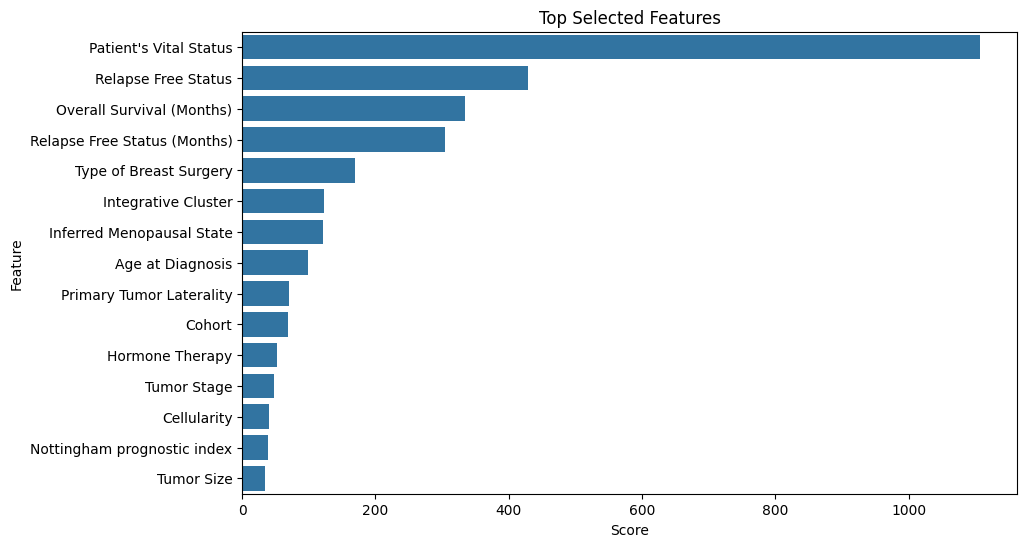

In [ ]:
plt.figure(figsize=(10,6))

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
})

feature_scores = feature_scores.sort_values(
    by='Score',
    ascending=False
)

sns.barplot(
    x='Score',
    y='Feature',
    data=feature_scores.head(15)
)

plt.title('Top Selected Features')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [ ]:
# Logistic Regression
lr_model = LogisticRegression()

lr_model.fit(
    X_train_selected,
    y_train
)

# Predictions
lr_pred = lr_model.predict(
    X_test_selected
)

# Metrics
print("Logistic Regression")

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1 Score:",
      f1_score(y_test, lr_pred))

Logistic Regression
Accuracy: 0.9860279441117764
Precision: 1.0
Recall: 0.9567901234567902
F1 Score: 0.9779179810725552


In [ ]:
# Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train_selected,
    y_train
)

# Predictions
dt_pred = dt_model.predict(
    X_test_selected
)

# Metrics
print("Decision Tree")

print("Accuracy:",
      accuracy_score(y_test, dt_pred))

print("Precision:",
      precision_score(y_test, dt_pred))

print("Recall:",
      recall_score(y_test, dt_pred))

print("F1 Score:",
      f1_score(y_test, dt_pred))

Decision Tree
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [ ]:
# Random Forest
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(
    X_train_selected,
    y_train
)

# Predictions
rf_pred = rf_model.predict(
    X_test_selected
)

# Metrics
print("Random Forest")

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Precision:",
      precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1 Score:",
      f1_score(y_test, rf_pred))

Random Forest
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.986028,1.0,0.95679,0.977918
1,Decision Tree,1.000000,1.0,1.00000,1.000000
2,Random Forest,1.000000,1.0,1.00000,1.000000


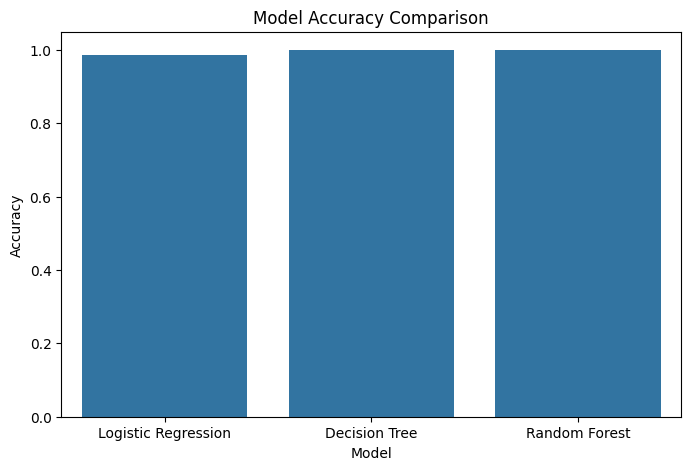

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title('Model Accuracy Comparison')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
# Parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

In [ ]:
# Random Forest model
rf = RandomForestClassifier(
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit model
grid_search.fit(
    X_train_selected,
    y_train
)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}


In [ ]:
best_rf = grid_search.best_estimator_

In [ ]:
# Predictions
best_pred = best_rf.predict(
    X_test_selected
)

# Metrics
print("Tuned Random Forest Performance")

print("Accuracy:",
      accuracy_score(y_test, best_pred))

print("Precision:",
      precision_score(y_test, best_pred))

print("Recall:",
      recall_score(y_test, best_pred))

print("F1 Score:",
      f1_score(y_test, best_pred))

Tuned Random Forest Performance
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [ ]:
print(
    classification_report(
        y_test,
        best_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       339
           1       1.00      1.00      1.00       162

    accuracy                           1.00       501
   macro avg       1.00      1.00      1.00       501
weighted avg       1.00      1.00      1.00       501



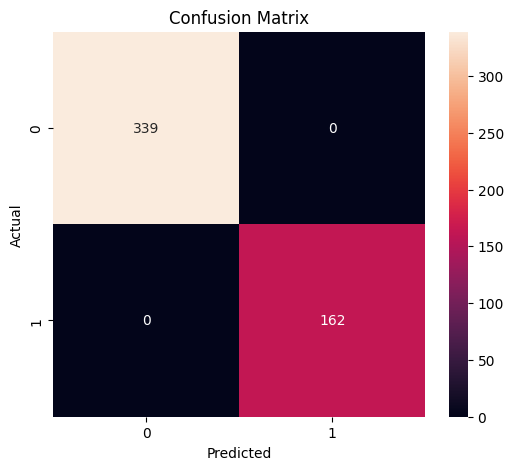

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    best_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

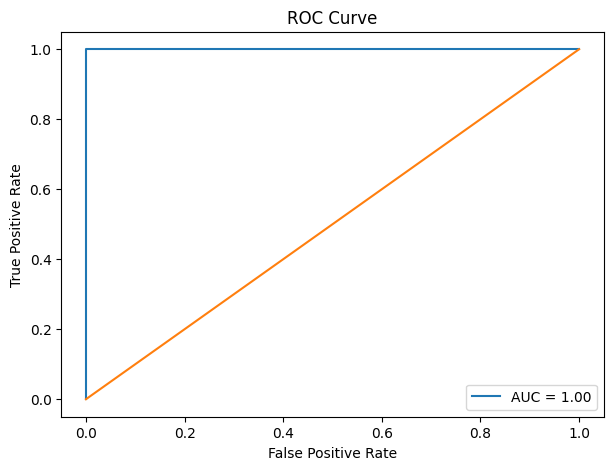

In [ ]:
from sklearn.metrics import roc_curve, auc

# Probability scores
y_prob = best_rf.predict_proba(
    X_test_selected
)[:,1]

# ROC
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot([0,1],[0,1])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')
plt.legend()

plt.show()

In [ ]:
import joblib
joblib.dump(
    best_rf,
    'breast_cancer_model.pkl'
)
joblib.dump(
    scaler,
    'scaler.pkl'
)
joblib.dump(
    selector,
    'selector.pkl'
)

['selector.pkl']

In [63]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 48.2 MB/s eta 0:00:00


In [65]:
streamlit run app.py

SyntaxError: invalid syntax (3737097518.py, line 1)